# RSS vs Distance from Transmitter

Find how the RSS varies as the bee's distance from a transmitter increases. Can this relationship be plotted as a linear graph?

Uses the `March 26 2025 Field Trial` data.

Axes:
    X = Distance from transmitter
    Y = RSS

In [2]:
import math

from BLEanalysis.signals import Signals
import matplotlib.pyplot as plt

gpsFilepath = "/home/finley/Git/bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv"

testdata = Signals("/home/finley/Git/bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log",['e'],filetype='log',angleOffset=0)

startingTime = 5
endingTime = 28

# configure the transmitter closest to the start point
# testdata.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
# testdata.summarise(showNormalised = False)

Standardising angles and times (shifting by 0.00 degrees)


1341


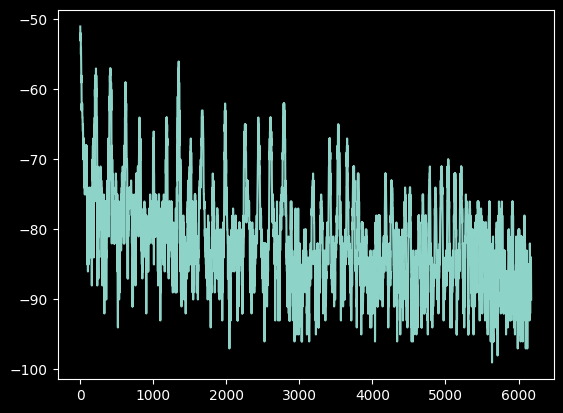

In [3]:
import numpy as np

# plot RSS over time (tmp)
print(np.argmax(testdata.data[:, 0]))
plt.plot(testdata.data[1341:, 0])

In [4]:
from BLEanalysis.signals import Signals
import numpy as np

def extract_every_rss_at_angle(ble_signals :Signals, theta :float):
    """
    Examines a given list of signals and returns all the RSS measurements
    taken at a given angle of theta. Leaves ~2s between each
    packet, allowing the transmitter to do a full rotation.
    Adapted from Mike's code in the meeting
    :param ble_signals: A log file parsed as Signals
    :param theta: The angle of rotation to extract RSS measurements, in radians
    :return: A list of RSS measurements
    :rtype: list
    """
    # extract the data, excluding the first 200
    ble_data = ble_signals.data[200:,:] #RSSI, ID, Angle, Time

    # index of the first packet with a gamma of approximately theta
    index_of_packet = np.argmin(np.abs(
        ble_data[(ble_data[:, -1] < ble_data[0, -1] + 201), 2] - theta
    ))

    rss_values = []

    # search through the entire log file until reaching the end
    try:
        while True:
            # range of time values of packets ~2s since the previous one
            search_start_time = ble_data[index_of_packet, 3] + 1750
            search_end_time = ble_data[index_of_packet, 3] + 2250

            # get indexes of packets ~2s since the previous one
            time_index_start = np.argmin(np.abs(ble_data[:,3] - search_start_time))
            time_index_end = np.argmin(np.abs(ble_data[:, 3] - search_end_time))

            # get the packet with the closest angle to theta
            index_of_packet = np.argmin(np.abs(ble_data[time_index_start:time_index_end, 2] - theta)) + time_index_start

            # check if the packet includes the angle we want
            if np.abs(ble_data[index_of_packet, 2] - theta) < 0.1:
                rss_values.append(ble_data[index_of_packet, 0])
    finally:
        #print(f"{len(rss_values)} RSS values found")
        return rss_values


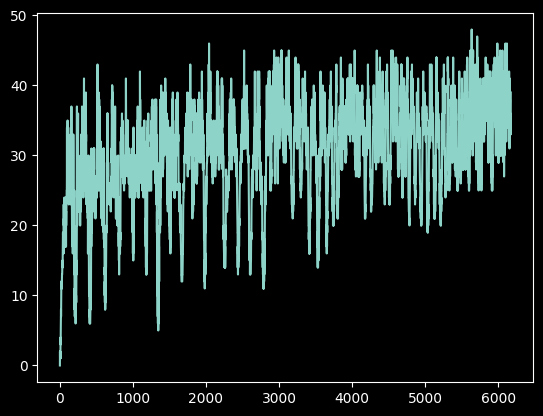

In [5]:
transmit_strength = -51.0 # at packet number 1341

# rsses = extract_every_rss_at_angle(testdata, 0.75 * math.pi)
rsses = np.subtract(testdata.data[1341:,0], transmit_strength)
rsses = np.multiply(rsses, -1)

plt.plot(rsses)

## Today's Conclusion

Attenuation is not considered random. It seems like it's not going to be easy to isolate the RSS at a given angle due to some packets missing at given angles and it being tricky to isolate the specific code required.

### Objective: Plot a graph of RSS vs Distance from Transmitter

Carry out a new experiment and log that data. Do it in an open space or field.

1. Disable the transmitter's spinning so it's always pointing in the same direction.
2. Walk away from the transmitter in a straight line and at a constant rate
3. Plot (RSS - Transmitted strength) vs distance

This will give us an expected RSS for a given distance. When computing the path, if the RSS varies too much from the value at the given distance, the packet can be ignored.

## Change in GPS Distance from the Start

The change in distance, as measured by the GPS sensor

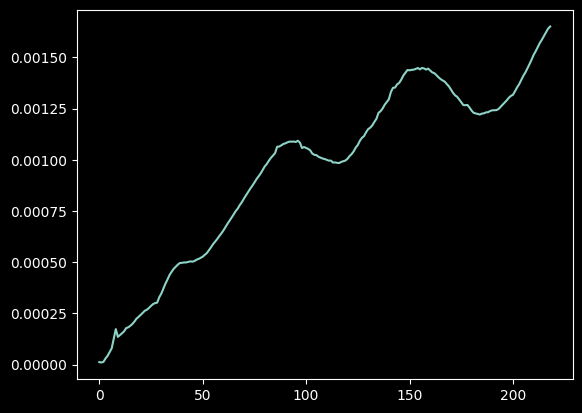

In [15]:
import math

with open(gpsFilepath) as file:
    filedata = file.read()

gpsData = filedata[299:].split('\n')

lat = []
lon = []
for coord in gpsData[:-1]:
    coord = coord.split(',')
    lat.append(float(coord[3]))
    lon.append(float(coord[4]))

start_coords = (lat[0], lon[0])
coords = []

for point in zip(lat[1:], lon[1:]):
    coords.append(math.sqrt((point[0] - start_coords[0])**2 + (point[1] - start_coords[1])**2))

plt.plot(coords)

# plot inverse of RSSes on the same graph
inverse_rss = []

for rss in testdata.data[200:, 0]:
    inverse_rss.append(rss**-1)

plt.plot(inverse_rss)
plt.show()

# Straight Line RSS Analysis

Trying to get a graph of RSS over distance using the straight path experiment data

In [9]:
from BLEanalysis.pathinference import Path_ProbabilityDensitiesToBee
from BLEanalysis.kernels import ExponentiatedQuadraticKernel
from BLEanalysis.signals import Signals
import numpy as np
import matplotlib.pyplot as plt

def draw_path(signals :Signals, gps_file_path :str, ending_time :int, starting_time = 5):
    """
    Condenses all methods/parameters called and required to construct
    the path of a tag and plot it on a graph along with the true GPS path.
    :param signals BLE signals received by the tag
    :param gps_file_path File path of the GPS data
    :param ending_time Time, in seconds, to stop plotting points at
    :param starting_time Time, in seconds, to start plotting points from
    :returns: Nothing - draws a graph
    """
    ls = 3 # Kernel length scale
    scale = 13 # Kernel scale factor
    nInd = 20 # Number of inducing points
    noise = 0.5 # Noise scale
    timeScale = 10000 # Scale time series down by this factor when preparing observations

    nSamps = 200 # Max number of samples to use per burst for path reconstruction
                # (2 second bursts, how many samples within that burst)
    burstLength = 2000 # in ms
    samplingMethod = "linspaceIdxs" # random, linspaceTimes, linspaceIdxs

    k = ExponentiatedQuadraticKernel(ls,scale)

    signals.configureTransmitter('c',0,0,transmitterLat = 53.368359, transmitterLon = -1.450168)
    signals.configureTransmitter('a',-(167340+194210),0,transmitterLat = 53.368606, transmitterLon = -1.448596)
    signals.configureTransmitter('b',-(167340+194210+121110),0,transmitterLat = 53.367865, transmitterLon = -1.448626)
    signals.configureTransmitter('e',-167340,0,transmitterLat = 53.369204, transmitterLon = -1.449990)
    # Normalise the transmitter locations around zero, in preparation for the observations
    signals.noramliseTransmitterLocs()
    signals.summarise(showNormalised = False)

    # --- main coordinate-calculating code ---
    obs = []
    obstimes = []
    burst, time = signals.parseBursts(burstInterval=0)
    for b in range(len(burst)):
        newburst = signals.subsampleBurst(burst[b], nSamps, burstLength, method=samplingMethod)
        obstimes.append(time[b])
        obs.append(newburst)

    # Scale down times and standardise times such that they start at zero
    time_min = np.min(obstimes)
    for i in range(len(obstimes)):
        obstimes[i] = (obstimes[i] - time_min) / timeScale

    path = Path_ProbabilityDensitiesToBee(np.array(obstimes),obs,k,noise,nInd, margin = np.max(obstimes) * 0.2, jitter = 0.1)

    path.run(300,learning_rate=0.5, just_optimise_means = True)

    path.plot(startTime = starting_time+1, endTime = ending_time-2,
              transmitters = signals.transmitterLocations,
              ellipseInterval = 10, timeMultiplier = timeScale,
              coordScaleFactor = signals.coordNormalisationFactor,
              GPSFile = gps_file_path)
    plt.title("Path Inferred from Probability Distributions")
    plt.show()

Standardising angles and times (shifting by 0.00 degrees)
Transmitter       Number of records
        a                 8467
        b                 3744
        c                14636
        e                 7515
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0: 2124757.8
iteration   50: 1536131.9
iteration  100: 1203000.1
iteration  150: 1025228.8
iteration  200:  939446.6
iteration  250:  930702.1


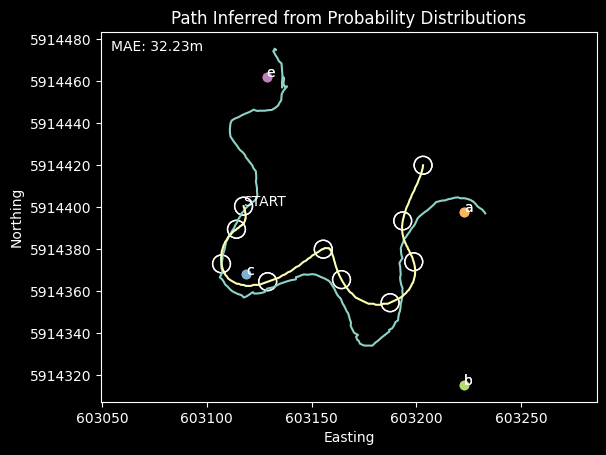

In [24]:
draw_path(
    Signals("../../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log",['c','a','b','e'],filetype='log',angleOffset=0),
    "../../bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv",
    28,
    10
)

## Straight Path 5

Investigating `straightpath5noperson` data

Standardising angles and times (shifting by 0.00 degrees)
Transmitter       Number of records
        a                 3771
        b                 5698
        c                 8028
        e                 5444
Standardising angles and times (shifting by 38.00 degrees)
Optimising mean...
iteration    0: 1740902.9
iteration   50: 1361102.6
iteration  100: 1092962.0
iteration  150: 1032626.6
iteration  200: 1024331.9
iteration  250: 1009534.4


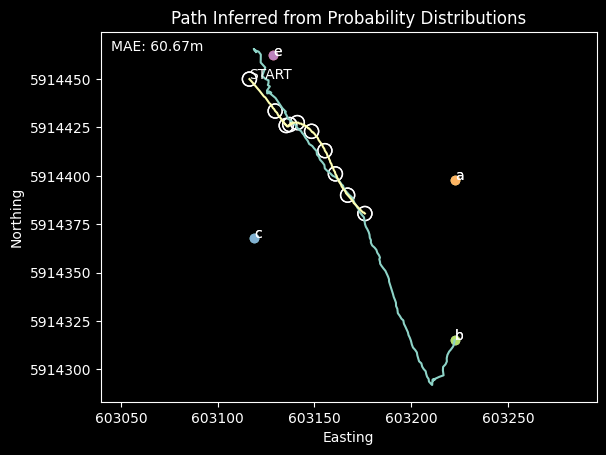

In [23]:
draw_path(
    Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['c','a','b','e'],filetype='log',angleOffset=0),
    "../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/2025-03-26_11_50_22_my_iOS_device.csv",
    15
)

Standardising angles and times (shifting by 0.00 degrees)


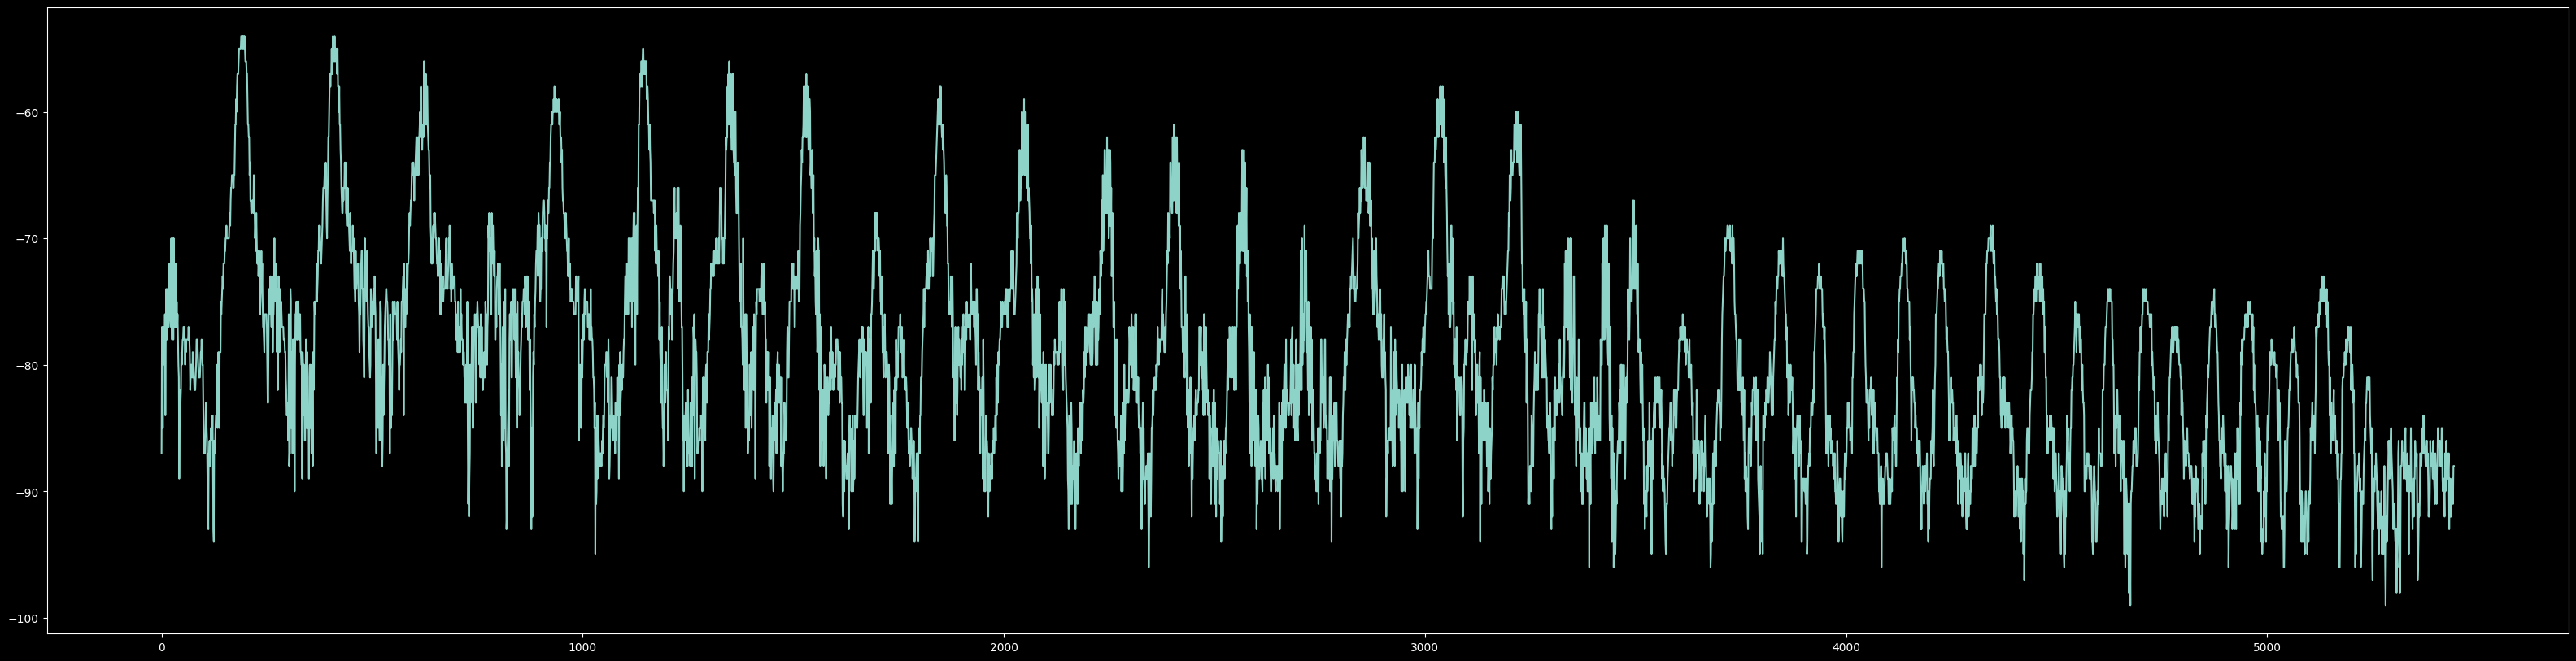

In [28]:
e_signals = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0)

plt.figure(figsize=(40,10))
plt.plot(e_signals.data[:,0])

Standardising angles and times (shifting by 0.00 degrees)
Transmitter       Number of records
        a                 4875
        b                 5257
        c                 9829
        e                 3626
Standardising angles and times (shifting by 38.00 degrees)


IndexError: list index out of range

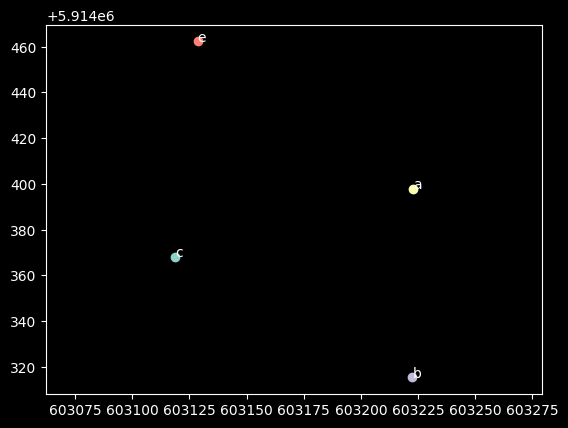

In [10]:
draw_path(
    Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath3/straightpath3.log", ['c','a','b','e'],filetype='log',angleOffset=0),
    "../../bluetooth_experiments/March 26 2025 Field Trial/straightpath3/2025-03-26_11_42_42_my_iOS_device.csv",
    10
)